In [120]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
data_dir = r"C:\Users\Admin\Desktop\ICH\Учеба, курсы в записи, домашки\Финальный проект\дополнительные файлы"

contacts = pd.read_csv(os.path.join(data_dir, "contacts_clean.csv"), dtype={"id": "string"})
calls = pd.read_csv(os.path.join(data_dir, "calls_clean.csv"), dtype={"id": "string", "contact_id": "string"})
deals = pd.read_csv(os.path.join(data_dir, "deals_clean.csv"), dtype={"id": "string", "contact_id": "string"})
spend = pd.read_csv(os.path.join(data_dir, "spend_clean.csv"))

In [122]:
contacts["created_time"] = pd.to_datetime(contacts["created_time"], errors="coerce")
contacts["modified_time"] = pd.to_datetime(contacts["modified_time"], errors="coerce")

calls["call_start_time"] = pd.to_datetime(calls["call_start_time"], errors="coerce")

deals["created_time"] = pd.to_datetime(deals["created_time"], errors="coerce")
deals["closing_date"] = pd.to_datetime(deals["closing_date"], errors="coerce")

spend["date"] = pd.to_datetime(spend["date"], errors="coerce")

In [123]:
def iqr_outlyer(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    outlier_arr = (df[column] < (q1 - k * iqr)) | (df[column] > (q3 + k * iqr))
    return outlier_arr

In [124]:
#Общая короткая статистика структуры таблиц из 4 файлов
datasets_summary = pd.DataFrame({
    "table": ["contacts", "calls", "deals", "spend"],
    "rows": [len(contacts), len(calls), len(deals), len(spend)],
    "columns": [contacts.shape[1], calls.shape[1], deals.shape[1], spend.shape[1]],
    "missing_total": [contacts.isna().sum().sum(), calls.isna().sum().sum(), deals.isna().sum().sum(), spend.isna().sum().sum()],
    "duplicates": [contacts.duplicated().sum(), calls.duplicated().sum(), deals.duplicated().sum(), spend.duplicated().sum()]
})

datasets_summary

,table,rows,columns,missing_total,duplicates
0,contacts,18510,5,0,0
1,calls,92617,8,3802,0
2,deals,19824,24,85216,0
3,spend,19862,8,0,0


# Contacts: описательная статистика

В таблице Contacts одна строка соответствует одному контакту CRM.  
Для описательной статистики не анализируем `id`, так как это технический идентификатор.

Смотрим:
- распределение контактов по менеджерам;
- даты создания и изменения контактов;
- длительность жизни контакта `contact_lifetime_days`;
- выбросы по `contact_lifetime_days`.

In [125]:
contacts.head()

,id,contact_owner_name,created_time,modified_time,contact_lifetime_days
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00,178.087500
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00,322.952778
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00,171.611111
3,5805028000000907006,Bob Brown,2023-07-03 05:44:00,2023-12-29 15:20:00,179.400000
4,5805028000000939010,Nina Scott,2023-07-04 10:11:00,2024-04-16 16:14:00,287.252083


In [126]:
contacts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18510 entries, 0 to 18509
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     18510 non-null  string        
 1   contact_owner_name     18510 non-null  object        
 2   created_time           18510 non-null  datetime64[ns]
 3   modified_time          18510 non-null  datetime64[ns]
 4   contact_lifetime_days  18510 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(1), string(1)
memory usage: 723.2+ KB


### Contacts: распределение по менеджерам

In [127]:
contacts_by_manager = (contacts["contact_owner_name"].value_counts().reset_index())

contacts_by_manager.columns = ["contact_owner_name", "contacts_count"]

contacts_by_manager["contacts_pct"] = (contacts_by_manager["contacts_count"] / len(contacts) * 100).round(2)

contacts_by_manager

,contact_owner_name,contacts_count,contacts_pct
0,Charlie Davis,2018,10.90
1,Ulysses Adams,1809,9.77
2,Julia Nelson,1769,9.56
3,Paula Underwood,1486,8.03
4,Quincy Vincent,1415,7.64
5,Nina Scott,1148,6.20
6,Ben Hall,1037,5.60
7,Victor Barnes,966,5.22
8,Cara Iverson,880,4.75
9,Rachel White,768,4.15


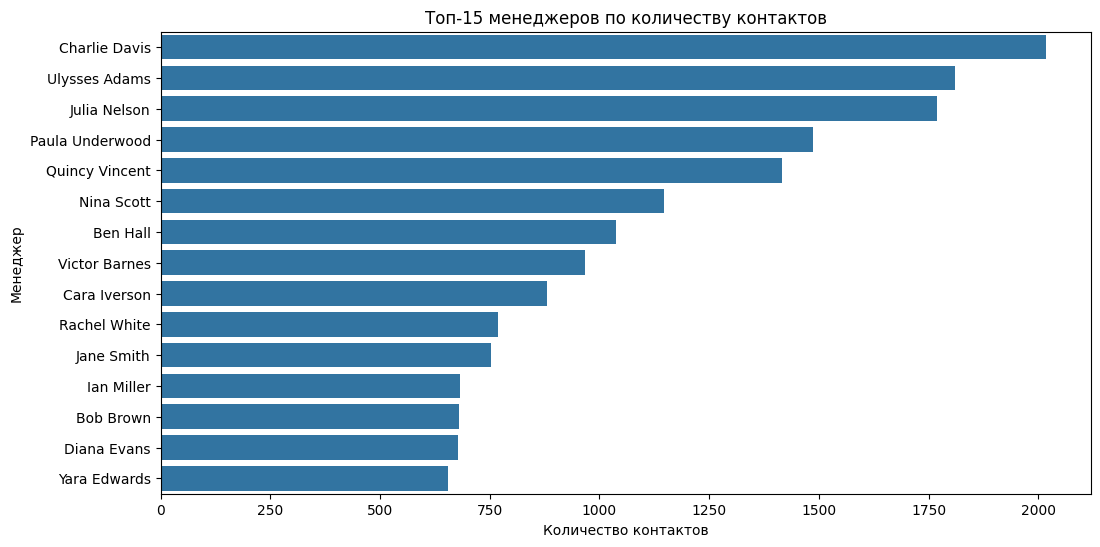

In [128]:
plt.figure(figsize=(12, 6))
sns.barplot(data=contacts_by_manager.head(15), x="contacts_count", y="contact_owner_name")
plt.title("Топ-15 менеджеров по количеству контактов")
plt.xlabel("Количество контактов")
plt.ylabel("Менеджер")
plt.show()

###  Contacts: даты создания и изменения

In [129]:
contacts_date_summary = pd.DataFrame({
    "metric": ["Минимальная дата создания", "Максимальная дата создания", "Минимальная дата изменения", "Максимальная дата изменения"],
    "value": [contacts["created_time"].min(), contacts["created_time"].max(), contacts["modified_time"].min(), contacts["modified_time"].max()]})

contacts_date_summary

,metric,value
0,Минимальная дата создания,2023-06-27 11:28:00
1,Максимальная дата создания,2024-06-21 15:30:00
2,Минимальная дата изменения,2023-07-06 10:54:00
3,Максимальная дата изменения,2024-06-21 15:32:00


In [130]:
# Кол-во контактов по месяцам
contacts_by_month = (contacts.assign(created_month=contacts["created_time"].dt.to_period("M").astype(str)).groupby("created_month").agg(contacts_count=("id", "count")).reset_index())

contacts_by_month

,created_month,contacts_count
0,2023-06,1
1,2023-07,627
2,2023-08,896
3,2023-09,991
4,2023-10,1456
5,2023-11,1571
6,2023-12,1668
7,2024-01,1984
8,2024-02,1728
9,2024-03,2007


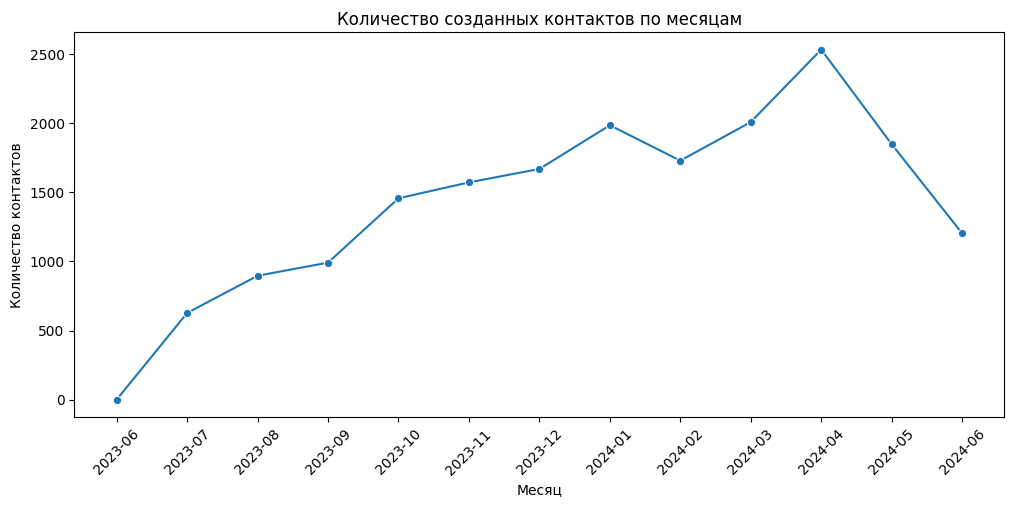

In [131]:
# график отображающий количество созданных контактов по месяцам
plt.figure(figsize=(12, 5))
sns.lineplot(data=contacts_by_month, x="created_month", y="contacts_count", marker="o")
plt.title("Количество созданных контактов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество контактов")
plt.xticks(rotation=45)
plt.show()

### Contacts: contact_lifetime_days

In [132]:
contacts["contact_lifetime_days"].describe()

count    18510.000000
mean        21.781356
std         53.529725
min          0.000000
25%          0.083333
50%          0.086111
75%          6.401736
max        350.563194
Name: contact_lifetime_days, dtype: float64

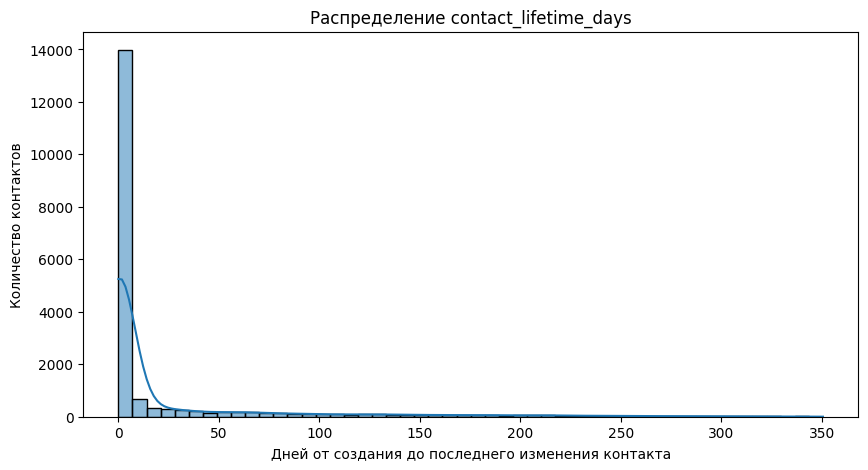

In [133]:
plt.figure(figsize=(10, 5))
sns.histplot(contacts["contact_lifetime_days"], bins=50, kde=True)
plt.title("Распределение contact_lifetime_days")
plt.xlabel("Дней от создания до последнего изменения контакта")
plt.ylabel("Количество контактов")
plt.show()

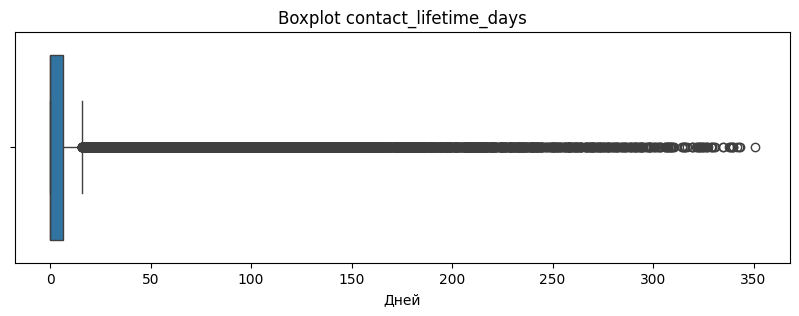

In [134]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=contacts["contact_lifetime_days"])
plt.title("Boxplot contact_lifetime_days")
plt.xlabel("Дней")
plt.show()

### Contacts: выбросы по IQR

In [135]:
contact_lifetime_outliers = iqr_outlyer(contacts, "contact_lifetime_days", k=1.5)

contact_lifetime_outliers_count = contact_lifetime_outliers.sum()
contact_lifetime_outliers_pct = round(contact_lifetime_outliers.mean() * 100, 2)

print("Количество выбросов:", contact_lifetime_outliers_count)
print("Доля выбросов:", contact_lifetime_outliers_pct, "%")

Количество выбросов: 3756
Доля выбросов: 20.29 %


In [136]:
contacts_lifetime_outliers = contacts[contact_lifetime_outliers].sort_values("contact_lifetime_days", ascending=False)

contacts_lifetime_outliers.head(20)

,id,contact_owner_name,created_time,modified_time,contact_lifetime_days
9,5805028000000968001,Jane Smith,2023-07-03 20:39:00,2024-06-18 10:10:00,350.563194
7,5805028000000964025,Ian Miller,2023-07-04 15:40:00,2024-06-11 18:40:00,343.125000
109,5805028000001593054,Bob Brown,2023-07-12 23:31:00,2024-06-19 23:11:00,342.986111
13,5805028000000983083,Rachel White,2023-07-04 14:06:00,2024-06-10 13:29:00,341.974306
173,5805028000001868133,Bob Brown,2023-07-14 23:15:00,2024-06-18 23:11:00,339.997222
37,5805028000001204013,Jane Smith,2023-07-07 06:52:00,2024-06-10 22:06:00,339.634722
42,5805028000001325013,Alice Johnson,2023-07-07 18:47:00,2024-06-10 22:32:00,339.156250
144,5805028000001837086,Bob Brown,2023-07-15 00:17:00,2024-06-17 21:18:00,338.875694
79,5805028000001404007,Jane Smith,2023-07-08 11:28:00,2024-06-10 23:14:00,338.490278
97,5805028000001500050,Jane Smith,2023-07-12 10:49:00,2024-06-14 07:08:00,337.846528


## Вывод по Contacts

В таблице Contacts нет пропусков и дублей после очистки.  
Основное распределение контактов по менеджерам неравномерное: часть менеджеров ведет значительно больше контактов, чем остальные это показывает barplot ТОП 15.

Даты создания контактов охватывают период от первой до последней регистрации в CRM. Распределение по месяцам позволяет увидеть динамику поступления новых контактов (так же отображено на lineplot).

По показателю `contact_lifetime_days` есть длинный правый хвост: большинство контактов изменялись вскоре после создания, но часть контактов обновлялась спустя значительно большее количество дней. Такие значения определяются как выбросы по правилу IQR, однако их не нужно удалять: они могут отражать долгую историю работы с клиентом или повторные изменения карточки в CRM. `Таких клиентов - 3756 и их доля - 20.29 %`

# Calls: описательная статистика
В таблице Calls одна строка соответствует одному звонку.  
Для описательной статистики не анализируем `id` и `contact_id`, так как это технические идентификаторы.

Смотрим:
- распределение звонков по менеджерам;
- типы звонков;
- статусы звонков;
- длительность звонков;
- долю успешных звонков;
- выбросы по длительности звонка.

In [137]:
calls.head()

,id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,is_successful_call
0,5805028000000764027,2023-06-30 08:59:00,John Doe,<NA>,Outbound,24,Attended Dialled,True
1,5805028000000768006,2023-06-30 08:46:00,John Doe,<NA>,Outbound,28,Attended Dialled,True
2,5805028000000768019,2023-06-30 09:30:00,John Doe,5805028000000645014,Outbound,11,Attended Dialled,True
3,5805028000000773022,2023-06-30 14:24:00,John Doe,5805028000000645014,Outbound,4,Attended Dialled,False
4,5805028000000787003,2023-06-30 09:20:00,John Doe,5805028000000645014,Outbound,6,Attended Dialled,True


In [138]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92617 entries, 0 to 92616
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        92617 non-null  string        
 1   call_start_time           92617 non-null  datetime64[ns]
 2   call_owner_name           92617 non-null  object        
 3   contact_id                88815 non-null  string        
 4   call_type                 92617 non-null  object        
 5   call_duration_in_seconds  92617 non-null  int64         
 6   call_status               92617 non-null  object        
 7   is_successful_call        92617 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(1), object(3), string(2)
memory usage: 5.0+ MB


### Calls: распределение по менеджерам

In [139]:
calls_by_manager = (calls["call_owner_name"].value_counts().reset_index())

calls_by_manager.columns = ["call_owner_name", "calls_count"]

calls_by_manager["calls_pct"] = (calls_by_manager["calls_count"] / len(calls) * 100).round(2)

calls_by_manager

,call_owner_name,calls_count,calls_pct
0,Yara Edwards,8532,9.21
1,Julia Nelson,7213,7.79
2,Ian Miller,7027,7.59
3,Charlie Davis,6943,7.50
4,Diana Evans,6713,7.25
5,Ulysses Adams,5961,6.44
6,Amy Green,5575,6.02
7,Victor Barnes,5361,5.79
8,Kevin Parker,5359,5.79
9,Nina Scott,5317,5.74


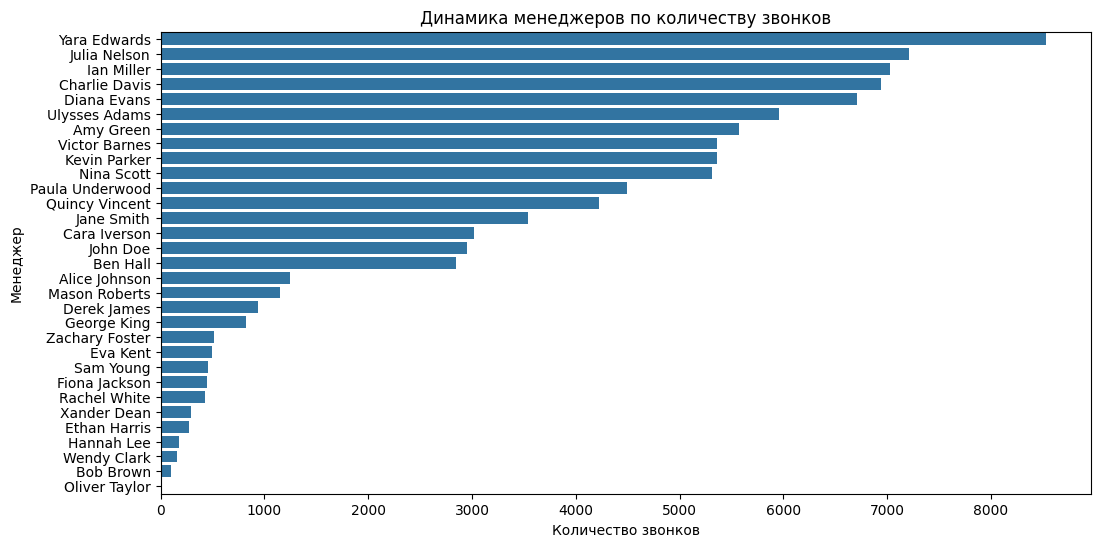

In [140]:
# график который показывает сколько звонков сделал каждый менеджер
plt.figure(figsize=(12, 6))
sns.barplot(data=calls_by_manager.head(31), x="calls_count", y="call_owner_name")
plt.title("Динамика менеджеров по количеству звонков")
plt.xlabel("Количество звонков")
plt.ylabel("Менеджер")
plt.show()

### Calls: типы звонков

In [141]:
call_type_summary = (calls["call_type"].value_counts(dropna=False).reset_index())

call_type_summary.columns = ["call_type", "calls_count"]

call_type_summary["calls_pct"] = (call_type_summary["calls_count"] / len(calls) * 100).round(2)

call_type_summary

,call_type,calls_count,calls_pct
0,Outbound,83804,90.48
1,Missed,5742,6.20
2,Inbound,3071,3.32


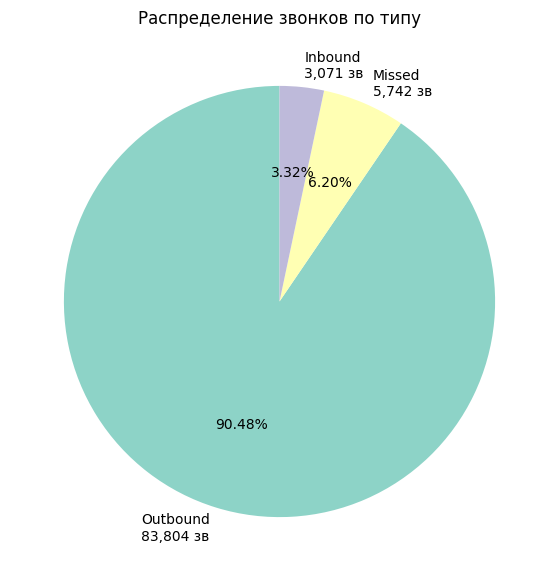

In [142]:
labels = [f"{row.call_type}\n{row.calls_count:,} зв"
    for row in call_type_summary.itertuples()]

plt.figure(figsize=(7, 7))

plt.pie(call_type_summary["calls_count"], labels=labels, autopct="%1.2f%%",
    startangle=90, colors=sns.color_palette("Set3", len(call_type_summary)))

plt.title("Распределение звонков по типу")
plt.show()

### Calls: статусы звонков

In [143]:
call_status_summary = (calls["call_status"].value_counts(dropna=False).reset_index())

call_status_summary.columns = ["call_status", "calls_count"]

call_status_summary["calls_pct"] = (call_status_summary["calls_count"] / len(calls) * 100).round(2)

call_status_summary

,call_status,calls_count,calls_pct
0,Attended Dialled,69522,75.06
1,Unattended Dialled,14146,15.27
2,Missed,5743,6.20
3,Received,3070,3.31
4,Overdue,57,0.06
5,Scheduled Attended Delay,20,0.02
6,Cancelled,19,0.02
7,Scheduled Unattended Delay,17,0.02
8,Scheduled Attended,14,0.02
9,Scheduled Unattended,6,0.01


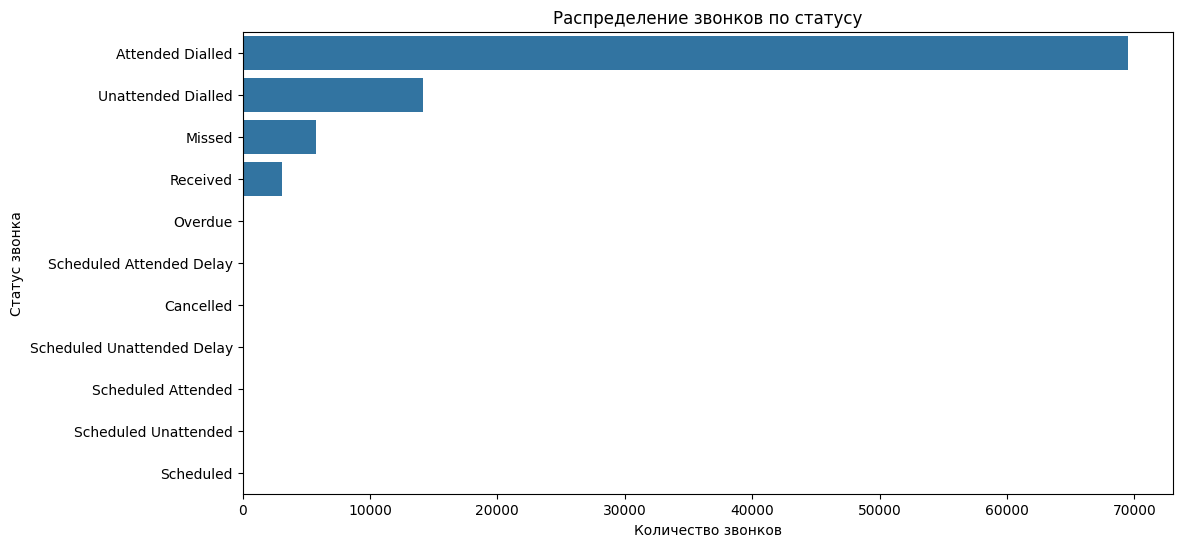

In [144]:
plt.figure(figsize=(12, 6))
sns.barplot(data=call_status_summary, x="calls_count", y="call_status")
plt.title("Распределение звонков по статусу")
plt.xlabel("Количество звонков")
plt.ylabel("Статус звонка")
plt.show()

### Calls: успешные звонки
Успешным звонком мы определили при чистке файлов звонки со статусом Attended Dialled или Received и длительностью больше 5 секунд.

In [145]:
successful_call_summary = (calls["is_successful_call"].value_counts(dropna=False).reset_index())

successful_call_summary.columns = ["is_successful_call", "calls_count"]

successful_call_summary["calls_pct"] = (successful_call_summary["calls_count"] / len(calls) * 100).round(2)

successful_call_summary


,is_successful_call,calls_count,calls_pct
0,True,57553,62.14
1,False,35064,37.86


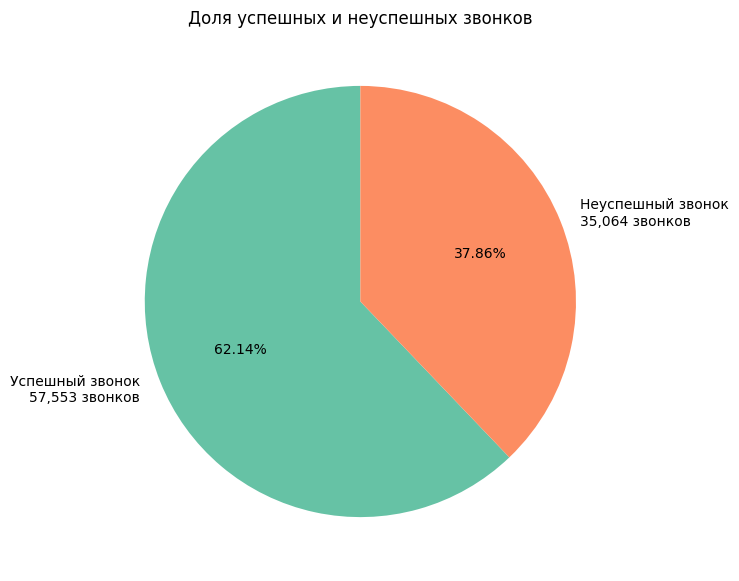

In [146]:
successful_call_summary["status"] = successful_call_summary["is_successful_call"].map({
    True: "Успешный звонок",
    False: "Неуспешный звонок"})

labels = [f"{row.status}\n{row.calls_count:,} звонков"
    for row in successful_call_summary.itertuples()]

plt.figure(figsize=(7, 7))

plt.pie(successful_call_summary["calls_count"], labels=labels, autopct="%1.2f%%", startangle=90,
        colors=sns.color_palette("Set2", len(successful_call_summary)))

plt.title("Доля успешных и неуспешных звонков")
plt.show()



### Calls: длительность звонков

In [147]:
calls["call_duration_in_seconds"].describe()

count    92617.000000
mean       170.184890
std        406.801264
min          0.000000
25%          4.000000
50%          9.000000
75%        107.000000
max       7625.000000
Name: call_duration_in_seconds, dtype: float64

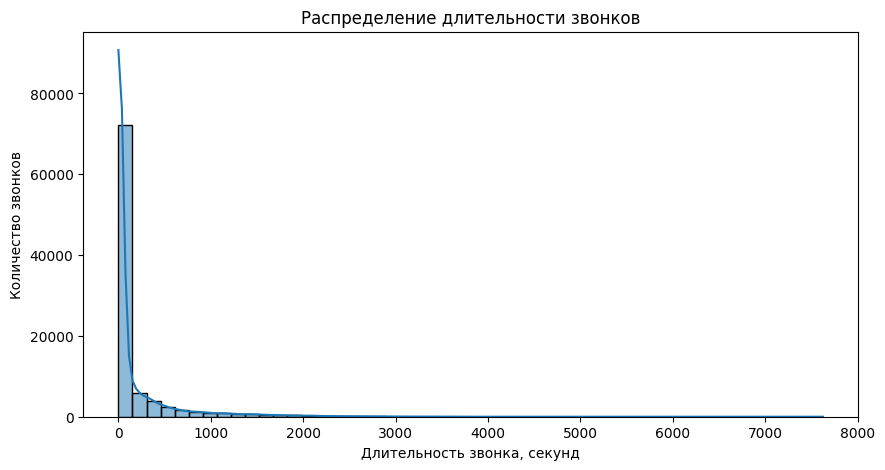

In [148]:
plt.figure(figsize=(10, 5))
sns.histplot(calls["call_duration_in_seconds"], bins=50, kde=True)
plt.title("Распределение длительности звонков")
plt.xlabel("Длительность звонка, секунд")
plt.ylabel("Количество звонков")
plt.show()

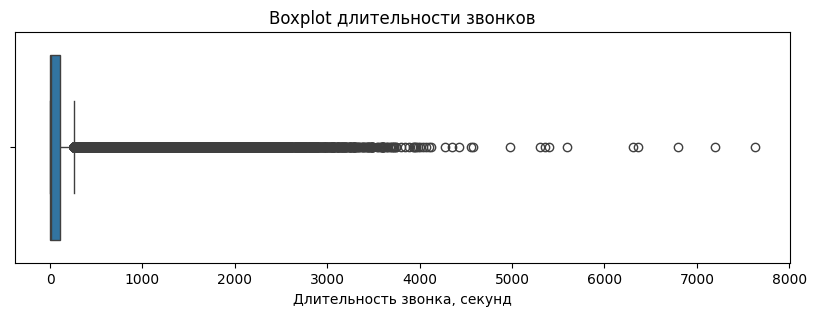

In [149]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=calls["call_duration_in_seconds"])
plt.title("Boxplot длительности звонков")
plt.xlabel("Длительность звонка, секунд")
plt.show()

In [150]:
call_duration_outliers = iqr_outlyer(calls, "call_duration_in_seconds", k=1.5)

call_duration_outliers_count = call_duration_outliers.sum()
call_duration_outliers_pct = round(call_duration_outliers.mean() * 100, 2)

print("Количество выбросов:", call_duration_outliers_count)
print("Доля выбросов:", call_duration_outliers_pct, "%")

Количество выбросов: 15868
Доля выбросов: 17.13 %


In [151]:
calls_duration_outliers = calls[call_duration_outliers].sort_values("call_duration_in_seconds", ascending=False)
calls_duration_outliers.head()

,id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,is_successful_call
28557,5805028000021593632,2023-12-15 19:05:00,Sam Young,5805028000021404645,Outbound,7625,Attended Dialled,True
76329,5805028000049344069,2024-05-10 17:34:00,Victor Barnes,5805028000047779175,Outbound,7200,Attended Dialled,True
54678,5805028000037508725,2024-03-14 19:46:00,John Doe,5805028000021062552,Inbound,6798,Received,True
28196,5805028000021415097,2023-12-14 15:49:00,Sam Young,5805028000021263687,Outbound,6368,Attended Dialled,True
65521,5805028000043303087,2024-04-11 16:00:00,Charlie Davis,5805028000041617254,Outbound,6304,Attended Dialled,True


## Вывод по Calls

В таблице Calls после очистки нет полных дублей и отрицательных длительностей звонков.  
Большая часть звонков относится к исходящим звонкам, что логично для отдела продаж.

По длительности звонков наблюдается сильная асимметрия: много коротких или неуспешных звонков и небольшая доля очень длинных разговоров (либо ошибка в заполнении).  
Boxplot и правило IQR выделяют длинные звонки как выбросы, однако удалять их не нужно: длительные разговоры могут быть реальными консультациями с клиентами и потенциально важны для анализа продаж (хотя звонки с длительностью ~ 7000 секунд - это почти 2 часа редкость но допустить можно, если бы там были разговоры 4 часа и более, то однозначно надо удалять такие данные).

Флаг `is_successful_call` позволяет отделить реальные успешные контакты от неуспешных попыток дозвона. Соответственно получили интересную информацию об успешности звонков. Но надо не забывать, что успешным звонком мы определили при чистке файлов звонки со статусом Attended Dialled или Received и длительностью больше 5 секунд. 

# Spend: описательная статистика
В таблице Spend одна строка соответствует рекламной статистике за дату, источник, кампанию, группу объявлений и объявление.

Для описательной статистики смотрим:
- распределение расходов по источникам;
- показы, клики и расходы;
- выбросы в числовых рекламных метриках;
- динамику расходов по времени.

Не анализируем `ad` и `adgroup`, так как это детальная рекламная информация с большим количеством значений, которые заполнялись каждым менеджером субьективно.

In [152]:
spend.head()

,date,source,campaign,impressions,spend,clicks,adgroup,ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,Unknown,Unknown
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,Unknown,Unknown
2,2023-07-03,Facebook Ads,Unknown,0,0.00,0,Unknown,Unknown
3,2023-07-03,Google Ads,Unknown,0,0.00,0,Unknown,Unknown
4,2023-07-03,CRM,Unknown,0,0.00,0,Unknown,Unknown


In [153]:
spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19862 entries, 0 to 19861
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19862 non-null  datetime64[ns]
 1   source       19862 non-null  object        
 2   campaign     19862 non-null  object        
 3   impressions  19862 non-null  int64         
 4   spend        19862 non-null  float64       
 5   clicks       19862 non-null  int64         
 6   adgroup      19862 non-null  object        
 7   ad           19862 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 1.2+ MB


### Spend: распределение по источникам

In [154]:
spend_by_source = (spend.groupby("source", dropna=False).agg(
        rows_count=("source", "count"),
        total_impressions=("impressions", "sum"),
        total_clicks=("clicks", "sum"),
        total_spend=("spend", "sum")).reset_index())

spend_by_source["spend_pct"] = (spend_by_source["total_spend"] / spend_by_source["total_spend"].sum() * 100).round(2)

spend_by_source = spend_by_source.sort_values("total_spend", ascending=False)

spend_by_source

,source,rows_count,total_impressions,total_clicks,total_spend,spend_pct
3,Google Ads,1266,32752334,248487,57798.60,38.66
2,Facebook Ads,9569,2850200,48133,33754.72,22.57
13,Youtube Ads,1784,8655978,59061,14633.33,9.79
0,Bloggers,632,738460,14250,13439.00,8.99
11,Tiktok Ads,2985,5007212,28268,11985.67,8.02
8,SMM,571,23772,11521,7269.52,4.86
9,Telegram posts,836,705415,16777,6860.36,4.59
12,Webinar,766,301670,3241,2874.04,1.92
10,Test,262,43969,1226,608.21,0.41
7,Radio,27,0,0,300.00,0.20


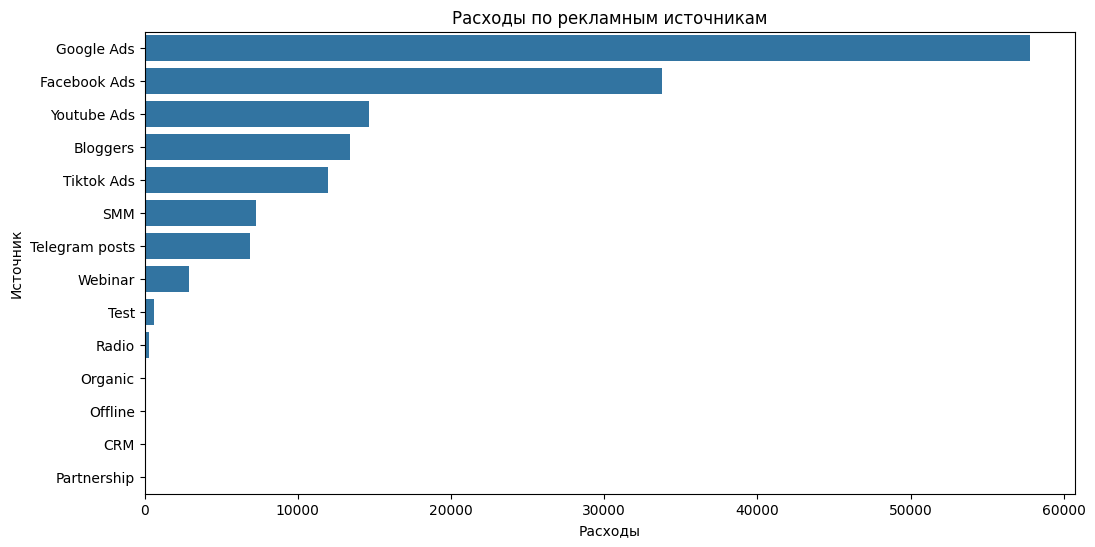

In [155]:
plt.figure(figsize=(12, 6))
sns.barplot(data=spend_by_source, x="total_spend", y="source")
plt.title("Расходы по рекламным источникам")
plt.xlabel("Расходы")
plt.ylabel("Источник")
plt.show()

# Spend: числовые поля

In [156]:
spend_numeric_columns = ["impressions", "clicks", "spend"]

spend[spend_numeric_columns].describe()

,impressions,clicks,spend
count,19862.000000,19862.000000,19862.000000
mean,2571.695197,25.095912,7.528117
std,11691.227016,87.032314,27.325150
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,82.000000,2.000000,0.740000
75%,760.750000,13.000000,6.160000
max,431445.000000,2415.000000,774.000000


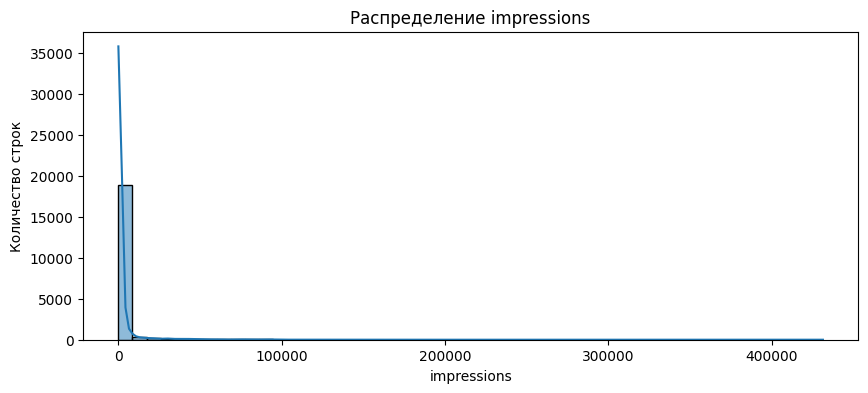

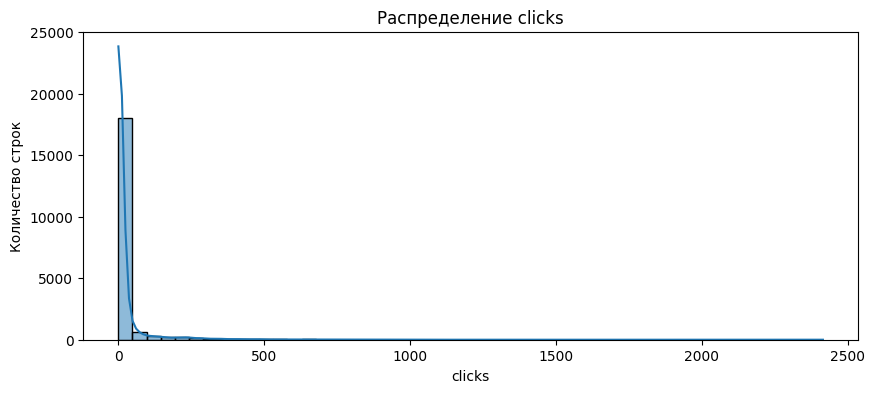

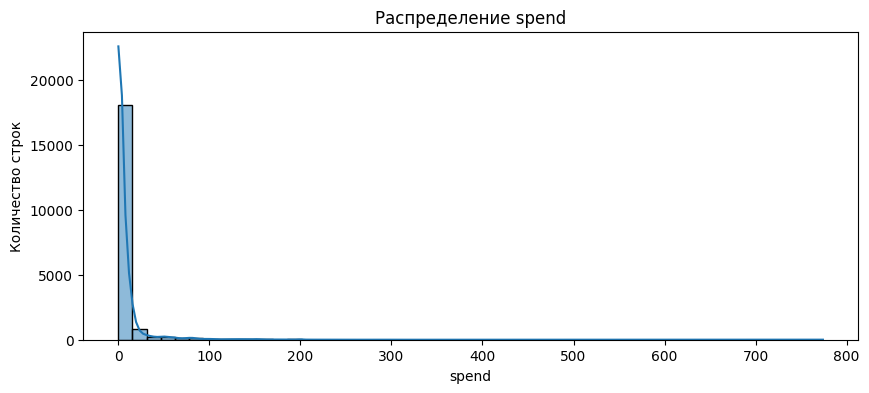

In [157]:
for col in spend_numeric_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(spend[col], bins=50, kde=True)
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество строк")
    plt.show()

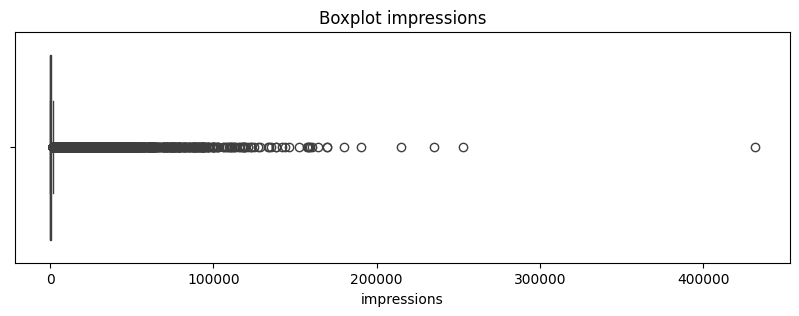

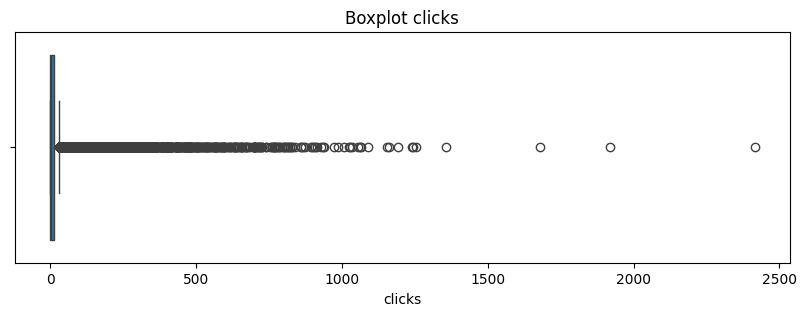

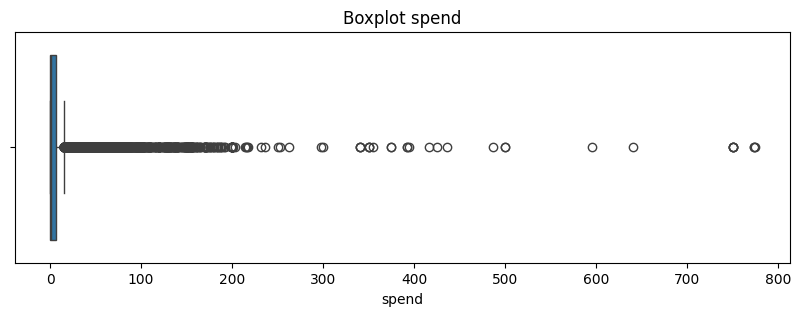

In [158]:
for col in spend_numeric_columns:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=spend[col])
    plt.title(f"Boxplot {col}")
    plt.xlabel(col)
    plt.show()

In [159]:
# Spend: выбросы по IQR
spend_outlier_summary = []

for col in spend_numeric_columns:
    outliers = iqr_outlyer(spend, col, k=1.5)
    
    spend_outlier_summary.append({
        "column": col,
        "outliers_count": outliers.sum(),
        "outliers_pct": round(outliers.mean() * 100, 2),
        "max_value": spend[col].max(),
        "median": spend[col].median()})

spend_outlier_summary = pd.DataFrame(spend_outlier_summary)

spend_outlier_summary

,column,outliers_count,outliers_pct,max_value,median
0,impressions,2633,13.26,431445.0,82.00
1,clicks,2400,12.08,2415.0,2.00
2,spend,1769,8.91,774.0,0.74


### Spend: динамика расходов по месяцам

In [160]:
spend_by_month = (spend.assign(month=spend["date"].dt.to_period("M").astype(str)).groupby("month").agg(
        total_spend=("spend", "sum"),
        total_impressions=("impressions", "sum"),
        total_clicks=("clicks", "sum")).reset_index())

spend_by_month

,month,total_spend,total_impressions,total_clicks
0,2023-07,6062.32,1868812,23553
1,2023-08,9033.73,3506308,35346
2,2023-09,8711.16,5554229,49103
3,2023-10,11807.78,4028456,50047
4,2023-11,10890.74,2214167,34108
5,2023-12,12186.03,3598888,42426
6,2024-01,12583.57,4388750,44298
7,2024-02,12476.83,3609747,40407
8,2024-03,16223.38,4572666,42920
9,2024-04,20964.65,8463518,61601


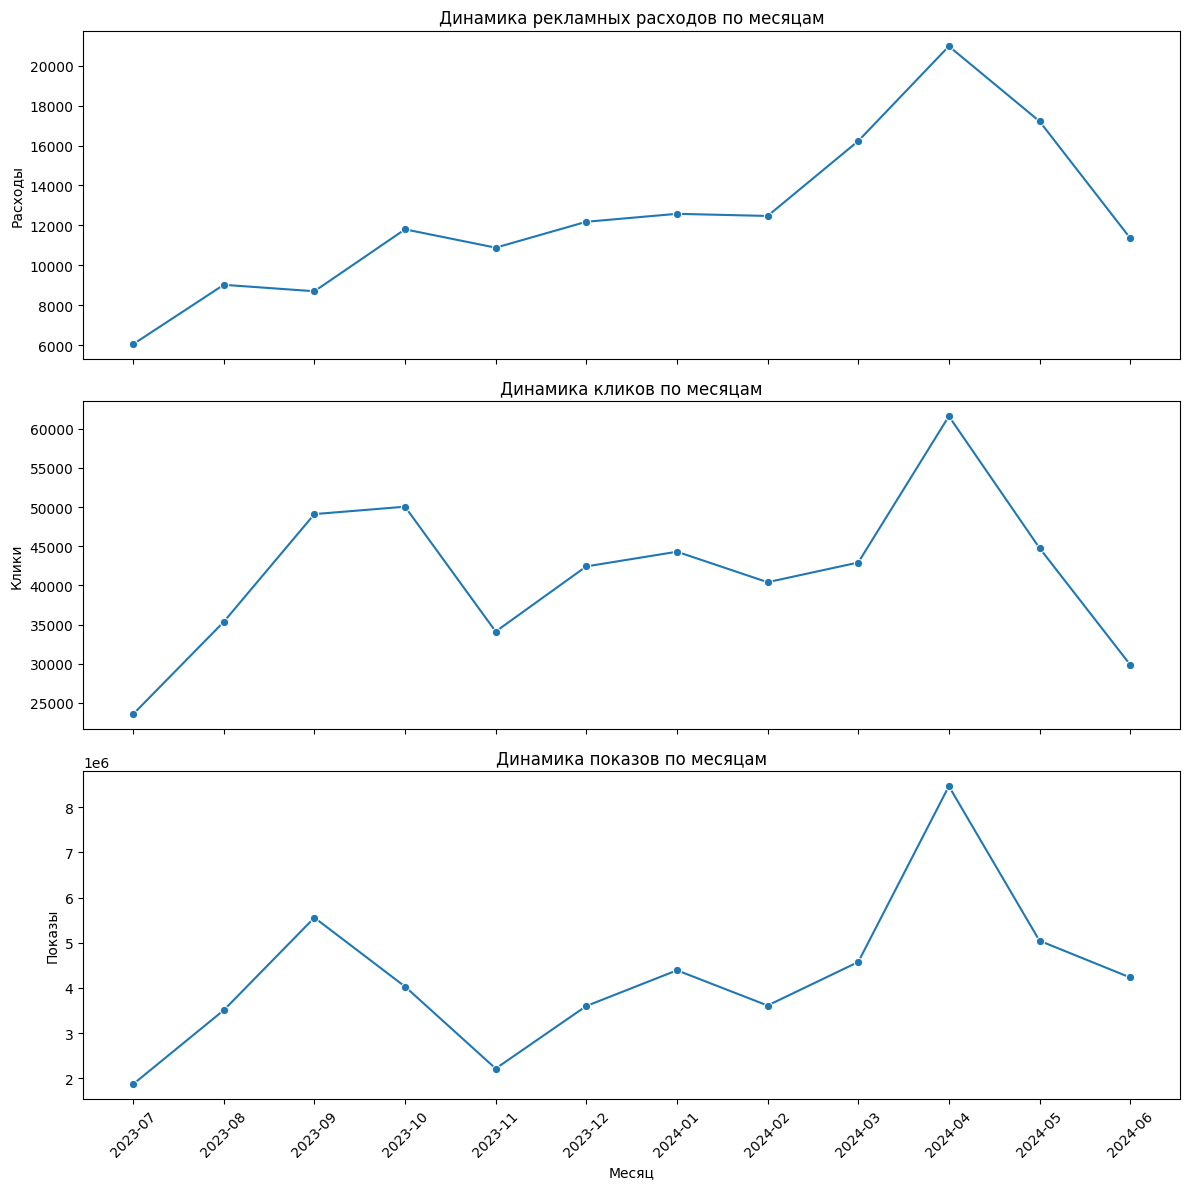

In [161]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(data=spend_by_month, x="month", y="total_spend", marker="o", ax=axes[0])
axes[0].set_title("Динамика рекламных расходов по месяцам")
axes[0].set_xlabel("")
axes[0].set_ylabel("Расходы")

sns.lineplot(data=spend_by_month, x="month", y="total_clicks", marker="o", ax=axes[1])
axes[1].set_title("Динамика кликов по месяцам")
axes[1].set_xlabel("")
axes[1].set_ylabel("Клики")

sns.lineplot(data=spend_by_month, x="month", y="total_impressions", marker="o", ax=axes[2])
axes[2].set_title("Динамика показов по месяцам")
axes[2].set_xlabel("Месяц")
axes[2].set_ylabel("Показы")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Расходы, клики и показы имеют разные масштабы, поэтому для сравнения динамики на одном графике значения были нормированы: максимум каждого показателя принят за 100%. Такой график показывает не абсолютные значения, а изменение метрик во времени относительно их собственного максимума.

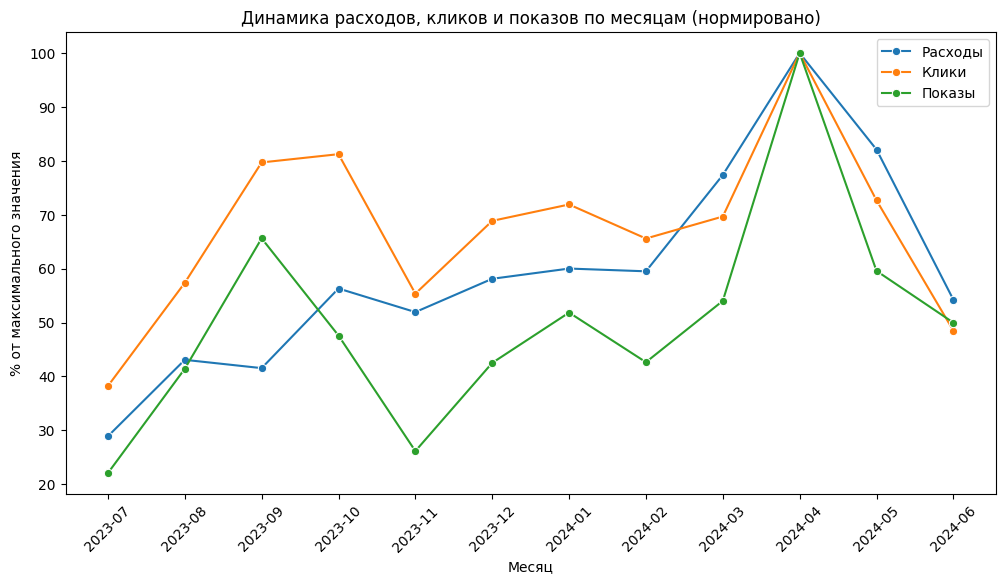

In [162]:
spend_by_month_normalized = spend_by_month.copy()

for col in ["total_spend", "total_clicks", "total_impressions"]:
    spend_by_month_normalized[col + "_norm"] = (spend_by_month_normalized[col]/ spend_by_month_normalized[col].max() * 100)

plt.figure(figsize=(12, 6))

sns.lineplot(data=spend_by_month_normalized, x="month", y="total_spend_norm", marker="o", label="Расходы")

sns.lineplot(data=spend_by_month_normalized, x="month", y="total_clicks_norm", marker="o", label="Клики")

sns.lineplot(data=spend_by_month_normalized, x="month", y="total_impressions_norm", marker="o", label="Показы")

plt.title("Динамика расходов, кликов и показов по месяцам (нормировано)")
plt.xlabel("Месяц")
plt.ylabel("% от максимального значения")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Вывод по Spend

В таблице Spend после очистки нет пропусков и дублей.  
Основные числовые поля — `impressions`, `clicks`, `spend`.

Рекламные расходы распределены неравномерно между источниками: часть каналов занимает основную долю бюджета, а часть источников имеет нулевые или минимальные расходы.

Для `impressions`, `clicks` и `spend` наблюдаются выбросы по boxplot и по IQR. Такие значения не удаляем, так как в рекламе высокие значения могут быть реальными: крупные кампании, дни с повышенным бюджетом или массовыми показами.

Динамика расходов по месяцам будет использоваться дальше для анализа эффективности рекламных источников и связи расходов с количеством лидов и студентов.

По месяцам дополнительно построена динамика расходов, кликов и показов. Это позволяет увидеть, совпадают ли изменения бюджета с изменением рекламной активности. Если расходы растут, но клики или показы не растут пропорционально, это может указывать на ухудшение эффективности рекламы или изменение структуры кампаний. Позже попробуем понять есть ли корреляция.

# Deals: описательная статистика
Таблица Deals — основная таблица проекта. Одна строка соответствует потенциальной сделке в CRM.

Для описательной статистики не анализируем `id` и `contact_id`, так как это технические идентификаторы.

Смотрим:
- менеджеров сделок;
- стадии сделок;
- причины потерь;
- источники;
- продукты и типы обучения;
- студентов (`is_student`), его мы определили во время чистки;
- SLA;
- месяцы обучения;
- денежные поля;
- выбросы по числовым полям.

In [163]:
deals.head()

,id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,content,...,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,is_student
0,5805028000005176025,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,Morning,2023-08-18 19:42:00,11.0,NaN,NaN,NaN,5805028000000872003,Unknown,Unknown,False
1,5805028000005168037,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,Morning,2023-08-18 19:45:00,11.0,NaN,NaN,NaN,5805028000000872003,Unknown,Unknown,False
2,5805028000005174051,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,Morning,2023-08-18 19:54:00,11.0,NaN,NaN,NaN,5805028000000872003,Unknown,Unknown,False
3,5805028000005180061,John Doe,NaT,E - Non Qualified,Registered on Webinar,NaN,/workshop,web2408_DE,5422.58,Unknown,...,Morning,2023-08-18 19:58:00,11.0,NaN,100.0,4000.0,5805028000000872003,Unknown,Unknown,False
4,5805028000005176076,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,Evening,2023-08-18 20:22:00,11.0,NaN,NaN,NaN,5805028000000872003,Unknown,Unknown,False


In [164]:
deals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19824 entries, 0 to 19823
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   19824 non-null  string        
 1   deal_owner_name      19795 non-null  object        
 2   closing_date         13138 non-null  datetime64[ns]
 3   quality              17588 non-null  object        
 4   stage                19824 non-null  object        
 5   lost_reason          14355 non-null  object        
 6   page                 19824 non-null  object        
 7   campaign             19824 non-null  object        
 8   sla                  14997 non-null  float64       
 9   content              19824 non-null  object        
 10  term                 19824 non-null  object        
 11  source               19824 non-null  object        
 12  payment_type         19824 non-null  object        
 13  product              19824 non-

# Deals: менеджеры сделок

In [165]:
deals_by_manager = (deals["deal_owner_name"].value_counts(dropna=False).reset_index())

deals_by_manager.columns = ["deal_owner_name", "deals_count"]

deals_by_manager["deals_pct"] = (deals_by_manager["deals_count"] / len(deals) * 100).round(2)

deals_by_manager.head(20)

,deal_owner_name,deals_count,deals_pct
0,Charlie Davis,2799,14.12
1,Julia Nelson,2086,10.52
2,Ulysses Adams,2069,10.44
3,Quincy Vincent,1805,9.11
4,Paula Underwood,1771,8.93
5,Ben Hall,1303,6.57
6,Nina Scott,1218,6.14
7,Victor Barnes,1187,5.99
8,Cara Iverson,1034,5.22
9,Diana Evans,927,4.68


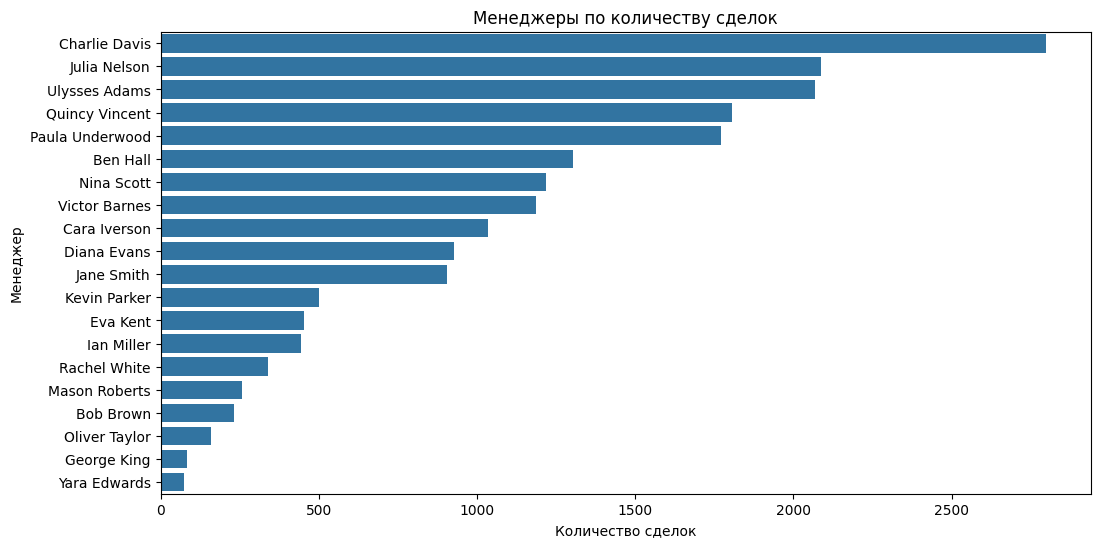

In [166]:
plt.figure(figsize=(12, 6))
sns.barplot(data=deals_by_manager.head(20), x="deals_count", y="deal_owner_name")
plt.title("Менеджеры по количеству сделок")
plt.xlabel("Количество сделок")
plt.ylabel("Менеджер")
plt.show()

### Deals: стадии сделок

In [167]:
stage_summary = (deals["stage"].value_counts(dropna=False).reset_index())

stage_summary.columns = ["stage", "deals_count"]

stage_summary["deals_pct"] = (stage_summary["deals_count"] / len(deals) * 100).round(2)

stage_summary

,stage,deals_count,deals_pct
0,Lost,13997,70.61
1,Call Delayed,2243,11.31
2,Registered on Webinar,2070,10.44
3,Payment Done,858,4.33
4,Waiting For Payment,324,1.63
5,Qualificated,128,0.65
6,Registered on Offline Day,85,0.43
7,Need to Call - Sales,33,0.17
8,Need To Call,31,0.16
9,Test Sent,25,0.13


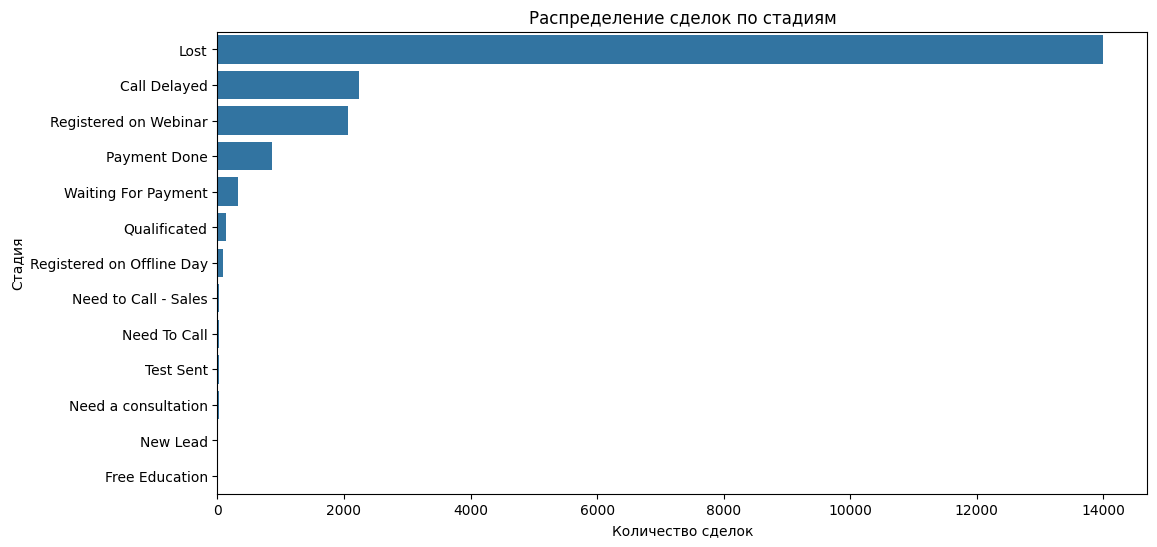

In [168]:
plt.figure(figsize=(12, 6))
sns.barplot(data=stage_summary, x="deals_count", y="stage")
plt.title("Распределение сделок по стадиям")
plt.xlabel("Количество сделок")
plt.ylabel("Стадия")
plt.show()

In [169]:
# Объединяем стадии меньше 1% чтобы построить график
stage_pie = stage_summary.copy()

stage_pie["stage_grouped"] = np.where(stage_pie["deals_pct"] < 1, "Other (<1%)", stage_pie["stage"])

stage_pie = (stage_pie.groupby("stage_grouped", as_index=False).agg(deals_count=("deals_count", "sum")))

stage_pie["deals_pct"] = (stage_pie["deals_count"] / stage_pie["deals_count"].sum() * 100).round(2)

stage_pie = stage_pie.sort_values("deals_count", ascending=False)

stage_pie

,stage_grouped,deals_count,deals_pct
1,Lost,13997,70.61
0,Call Delayed,2243,11.31
4,Registered on Webinar,2070,10.44
3,Payment Done,858,4.33
2,Other (<1%),332,1.67
5,Waiting For Payment,324,1.63


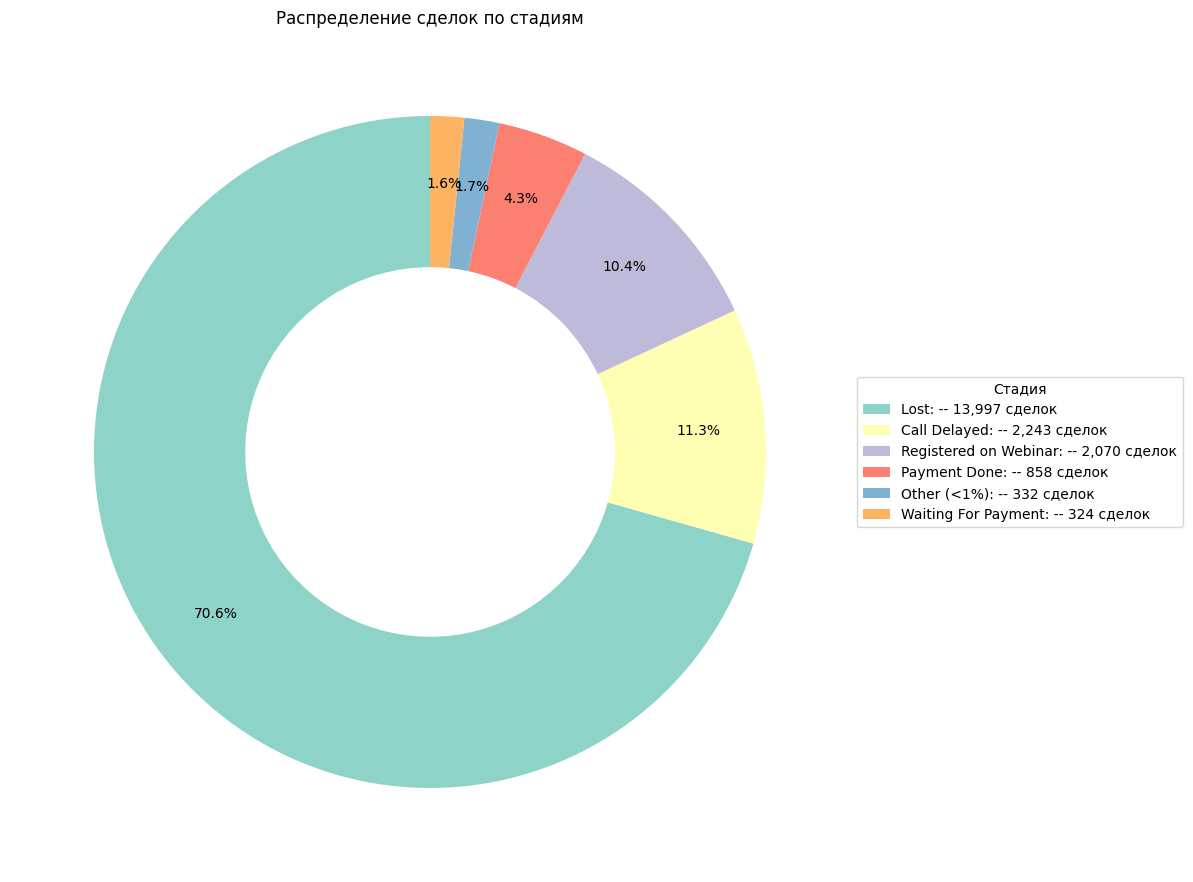

In [170]:
# Для визуализации стадий сделки категории с долей меньше 1% были объединены в группу `Other (<1%)`. 
# Это позволяет не перегружать круговую диаграмму редкими статусами и сохранить читаемость основных стадий.

plt.figure(figsize=(12, 12))

wedges, texts, autotexts = plt.pie(stage_pie["deals_count"], autopct="%1.1f%%", startangle=90, pctdistance=0.8, 
                                   colors=sns.color_palette("Set3", len(stage_pie)), wedgeprops={"width": 0.45})

plt.legend(wedges, [f"{row.stage_grouped}: -- {row.deals_count:,} сделок"
        for row in stage_pie.itertuples()], title="Стадия", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Распределение сделок по стадиям")
plt.tight_layout()
plt.show()

### Deals: студенты / buyer
Если months_of_study заполнен, клиент считается студентом/buyer, так как по условиям проекта это означает, что человек фактически начал обучение. На основе этого был создан столбец is_student.

In [171]:
student_summary = (deals["is_student"].value_counts(dropna=False).reset_index())

student_summary.columns = ["is_student", "deals_count"]

student_summary["deals_pct"] = (student_summary["deals_count"] / len(deals) * 100).round(2)

student_summary

,is_student,deals_count,deals_pct
0,False,18984,95.76
1,True,840,4.24


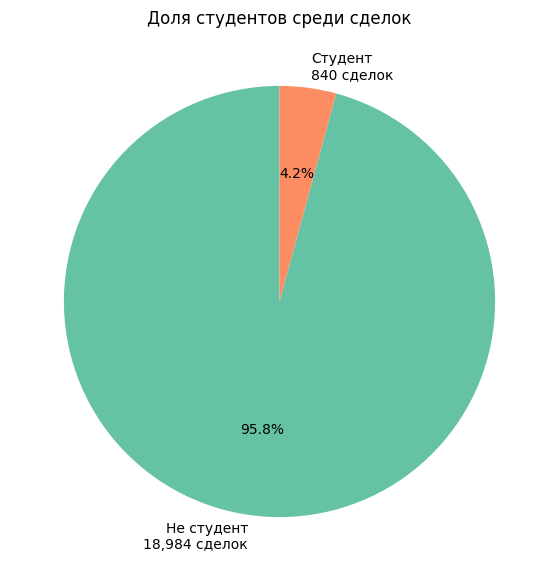

In [172]:
student_summary["status"] = np.where(student_summary["is_student"], "Студент", "Не студент")

labels = [f"{row.status}\n{row.deals_count:,} сделок"
    for row in student_summary.itertuples()]

plt.figure(figsize=(7, 7))
plt.pie(student_summary["deals_count"], labels=labels, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set2", len(student_summary)))
plt.title("Доля студентов среди сделок")
plt.show()


### Deals: причины потерь

In [173]:
lost_reason_summary = (deals["lost_reason"].value_counts(dropna=False).reset_index())

lost_reason_summary.columns = ["lost_reason", "deals_count"]

lost_reason_summary["deals_pct"] = (lost_reason_summary["deals_count"] / len(deals) * 100).round(2)

lost_reason_summary.head(20)

,lost_reason,deals_count,deals_pct
0,NaN,5469,27.59
1,Doesn't Answer,4135,20.86
2,Changed Decision,2146,10.83
3,Non target,1761,8.88
4,Stopped Answering,1588,8.01
5,Invalid number,1481,7.47
6,needs time to think,655,3.30
7,Expensive,626,3.16
8,Conditions are not suitable,531,2.68
9,Next stream,288,1.45


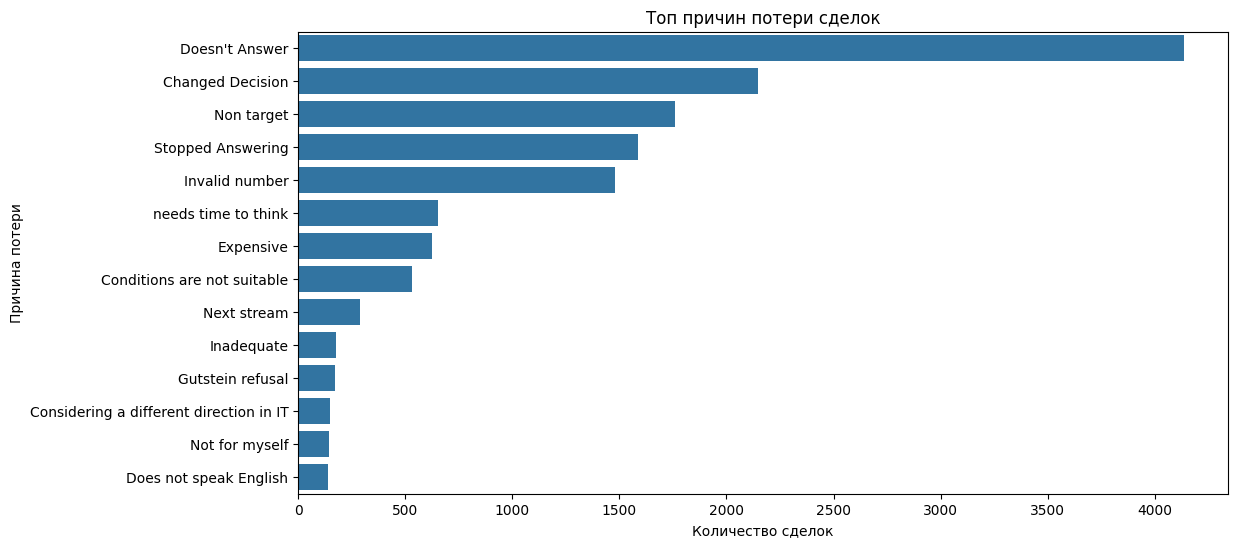

In [174]:
plt.figure(figsize=(12, 6))
sns.barplot(data=lost_reason_summary.head(15), x="deals_count", y="lost_reason")
plt.title("Топ причин потери сделок")
plt.xlabel("Количество сделок")
plt.ylabel("Причина потери")
plt.show()

### Deals: источники

In [175]:
deals_source_summary = (deals["source"].value_counts(dropna=False).reset_index())

deals_source_summary.columns = ["source", "deals_count"]

deals_source_summary["deals_pct"] = (deals_source_summary["deals_count"] / len(deals) * 100).round(2)

deals_source_summary

,source,deals_count,deals_pct
0,Facebook Ads,4730,23.86
1,Google Ads,4115,20.76
2,Tiktok Ads,2003,10.10
3,SMM,1669,8.42
4,Youtube Ads,1618,8.16
5,Organic,1499,7.56
6,CRM,1456,7.34
7,Bloggers,1074,5.42
8,Telegram posts,993,5.01
9,Webinar,306,1.54


In [176]:
# Для визуализации источников сделки источники с долей меньше 2% были объединены в группу `Other (<2%)
# Это позволяет сохранить читаемость диаграммы и сфокусироваться на основных каналах привлечения.

source_pie = deals_source_summary.copy()
source_pie["source_grouped"] = np.where(source_pie["deals_pct"] < 2, "Other (<2%)", source_pie["source"])
source_pie = (source_pie.groupby("source_grouped", as_index=False).agg(deals_count=("deals_count", "sum")))
source_pie["deals_pct"] = (source_pie["deals_count"] / source_pie["deals_count"].sum() * 100).round(2)
source_pie = source_pie.sort_values("deals_count", ascending=False)
source_pie

,source_grouped,deals_count,deals_pct
2,Facebook Ads,4730,23.86
3,Google Ads,4115,20.76
8,Tiktok Ads,2003,10.10
6,SMM,1669,8.42
9,Youtube Ads,1618,8.16
4,Organic,1499,7.56
1,CRM,1456,7.34
0,Bloggers,1074,5.42
7,Telegram posts,993,5.01
5,Other (<2%),667,3.36


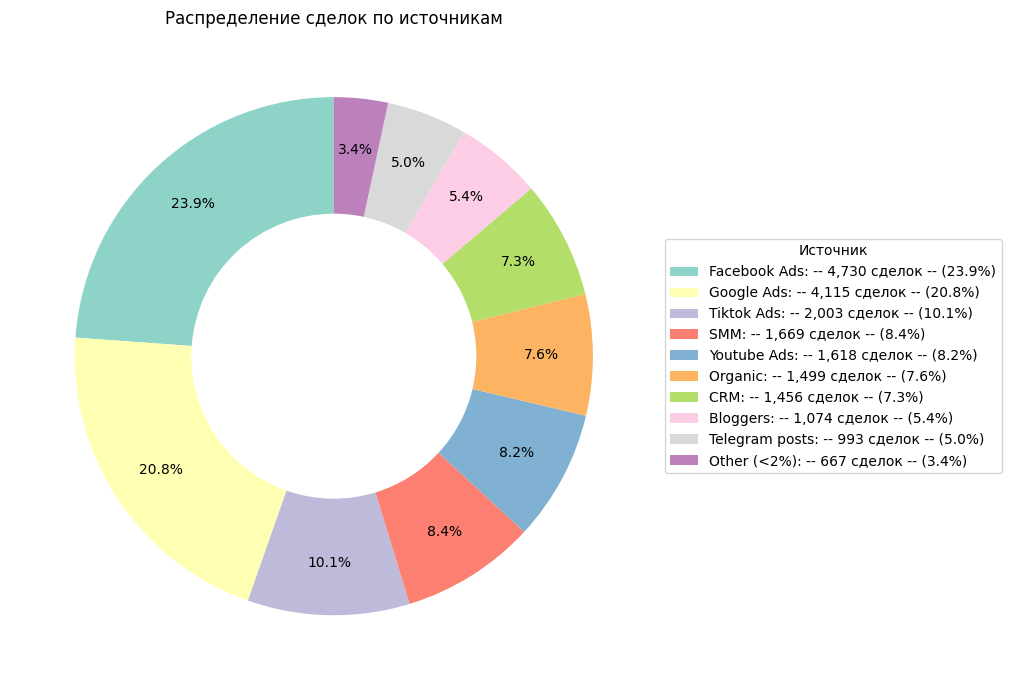

In [177]:

def autopct_format(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

plt.figure(figsize=(10, 7))

wedges, texts, autotexts = plt.pie(
    source_pie["deals_count"],
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.8,
    colors=sns.color_palette("Set3", len(source_pie)),
    wedgeprops={"width": 0.45})

plt.legend(wedges, [f"{row.source_grouped}: -- {row.deals_count:,} сделок -- ({row.deals_pct:.1f}%)"
        for row in source_pie.itertuples()],
    title="Источник",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Распределение сделок по источникам")
plt.tight_layout()
plt.show()

### Deals: продукты и типы обучения

In [178]:
product_summary = (deals["product"].value_counts(dropna=False).reset_index())

product_summary.columns = ["product", "deals_count"]

product_summary["deals_pct"] = (product_summary["deals_count"] / len(deals) * 100).round(2)

product_summary

,product,deals_count,deals_pct
0,Unknown,15430,77.83
1,Digital Marketing,2444,12.33
2,UX/UI Design,1216,6.13
3,Web Developer,714,3.60
4,Find yourself in IT,19,0.10
5,Data Analytics,1,0.01


In [179]:
education_type_summary = (deals["education_type"].value_counts(dropna=False).reset_index())
education_type_summary.columns = ["education_type", "deals_count"]
education_type_summary["deals_pct"] = (education_type_summary["deals_count"] / len(deals) * 100).round(2)
education_type_summary

,education_type,deals_count,deals_pct
0,Unknown,15749,79.44
1,Morning,3563,17.97
2,Evening,512,2.58


In [180]:
product_pie = product_summary.sort_values("deals_count", ascending=False)

education_pie = education_type_summary.sort_values("deals_count", ascending=False)

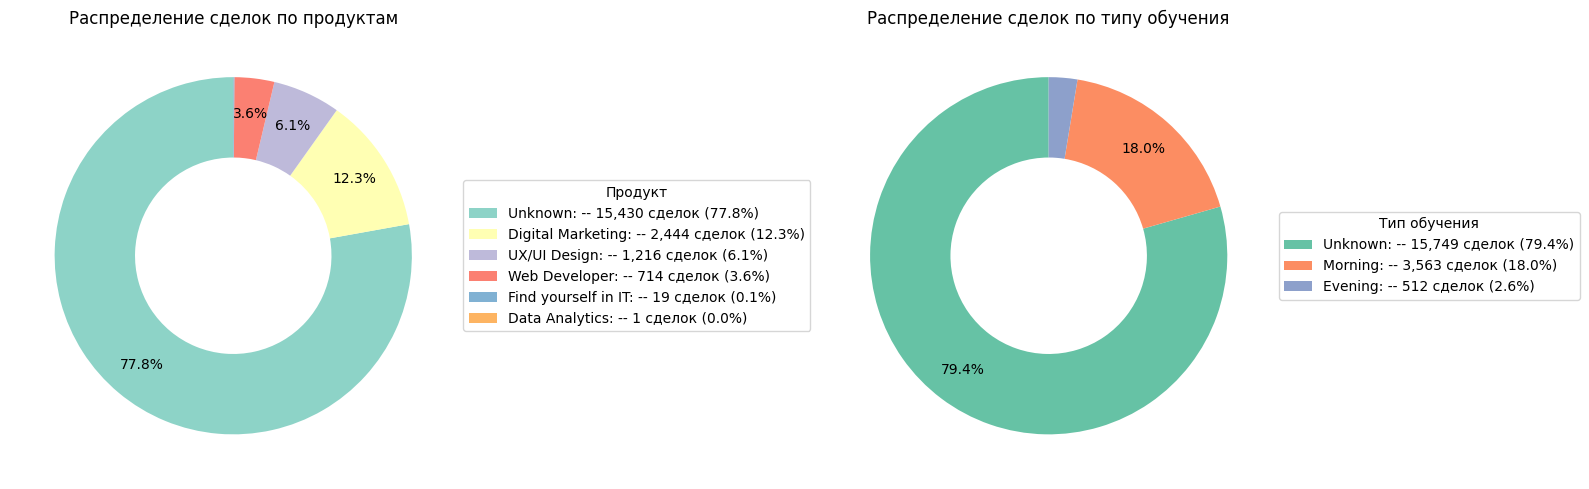

In [181]:
def autopct_format(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Products
wedges1, texts1, autotexts1 = axes[0].pie(
    product_pie["deals_count"],
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.8,
    colors=sns.color_palette("Set3", len(product_pie)),
    wedgeprops={"width": 0.45})

axes[0].legend(wedges1, [f"{row.product}: -- {row.deals_count:,} сделок ({row.deals_pct:.1f}%)"
        for row in product_pie.itertuples()],
    title="Продукт",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1))

axes[0].set_title("Распределение сделок по продуктам")

# Education Type
wedges2, texts2, autotexts2 = axes[1].pie(
    education_pie["deals_count"],
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.8,
    colors=sns.color_palette("Set2", len(education_pie)),
    wedgeprops={"width": 0.45})

axes[1].legend(wedges2, [f"{row.education_type}: -- {row.deals_count:,} сделок ({row.deals_pct:.1f}%)"
        for row in education_pie.itertuples()],
    title="Тип обучения",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1))

axes[1].set_title("Распределение сделок по типу обучения")

plt.tight_layout()
plt.show()

### Deals: числовые и дискретные поля
В Deals часть полей имеет числовой тип, но не все они являются непрерывными переменными.

Непрерывные числовые поля, для которых уместны `describe`, распределения, boxplot и IQR:
- `sla` — время ответа менеджера в минутах;
- `initial_amount_paid` — первый платеж;
- `offer_total_amount` — полная сумма предложения.

Отдельно рассматриваем поля, которые числовые по типу, но категориальные/дискретные по смыслу:
- `course_duration` — длительность курса в месяцах;
- `months_of_study` — количество месяцев обучения.

Для course_duration и months_of_study не используем boxplot и IQR как для непрерывных величин, а смотрим распределение значений через частоты и столбчатые диаграммы.

In [186]:
deals_numeric_columns = [
    "sla",
    "initial_amount_paid",
    "offer_total_amount"]

deals[deals_numeric_columns].describe()

,sla,initial_amount_paid,offer_total_amount
count,14997.000000,4062.000000,4082.000000
mean,1857.928822,950.150172,7216.930426
std,12107.872569,1391.506582,4595.251661
min,0.050000,0.000000,0.000000
25%,73.330000,300.000000,3500.000000
50%,329.850000,1000.000000,11000.000000
75%,932.200000,1000.000000,11000.000000
max,448474.400000,11500.000000,11500.000000


#### Deals: дискретные числовые поля
`course_duration` и `months_of_study` хранятся как числа, но по смыслу это ограниченный набор категорий. Поэтому анализируем их через частоты значений, а не как непрерывные переменные.

In [187]:
deals_discrete_columns = ["course_duration", "months_of_study"]

for col in deals_discrete_columns:
    discrete_summary = (deals[col].value_counts(dropna=False).rename_axis(col).reset_index(name="count"))
    
    discrete_summary["pct"] = (discrete_summary["count"] / len(deals) * 100).round(2)
    
    discrete_summary = discrete_summary.sort_values(by=col, na_position="last")
    
    print(f"\n{col}")
    display(discrete_summary)


course_duration


,course_duration,count,pct
2,6.0,714,3.60
1,11.0,3676,18.54
0,NaN,15434,77.86



months_of_study


,months_of_study,count,pct
12,0.0,1,0.01
7,1.0,67,0.34
2,2.0,104,0.52
3,3.0,94,0.47
4,4.0,93,0.47
8,5.0,64,0.32
1,6.0,107,0.54
6,7.0,79,0.40
5,8.0,83,0.42
9,9.0,61,0.31


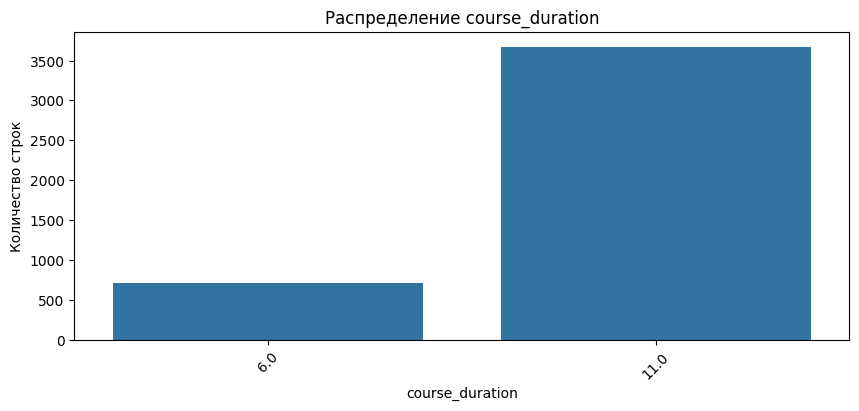

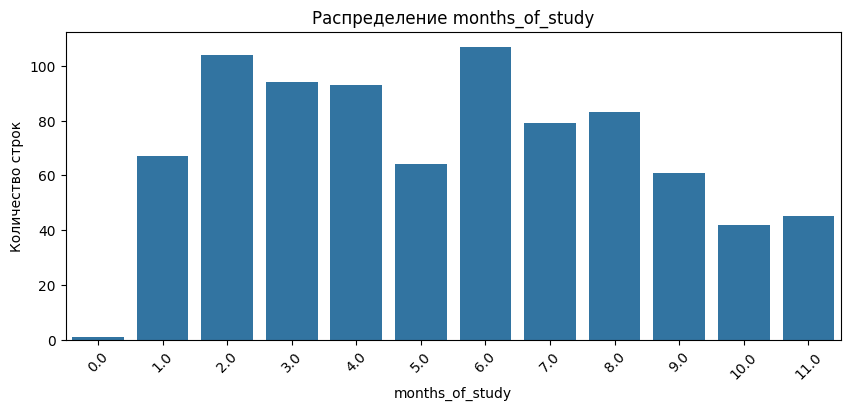

In [188]:
for col in deals_discrete_columns:
    order_values = sorted(deals[col].dropna().unique())
    
    plt.figure(figsize=(10, 4))
    sns.countplot(data=deals, x=col, order=order_values)
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество строк")
    plt.xticks(rotation=45)
    plt.show()

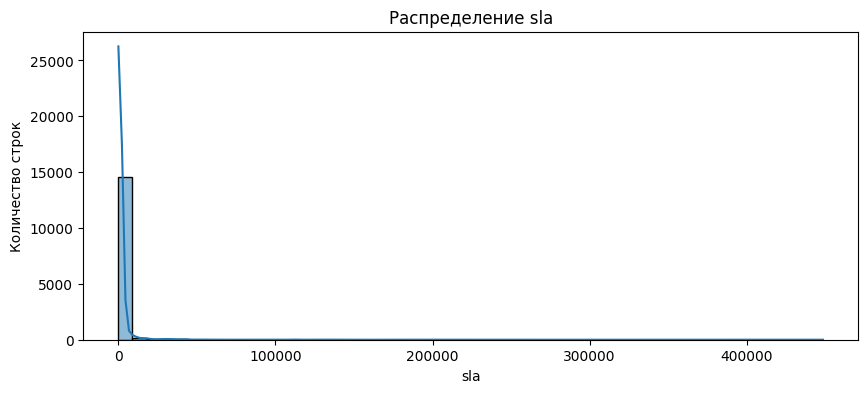

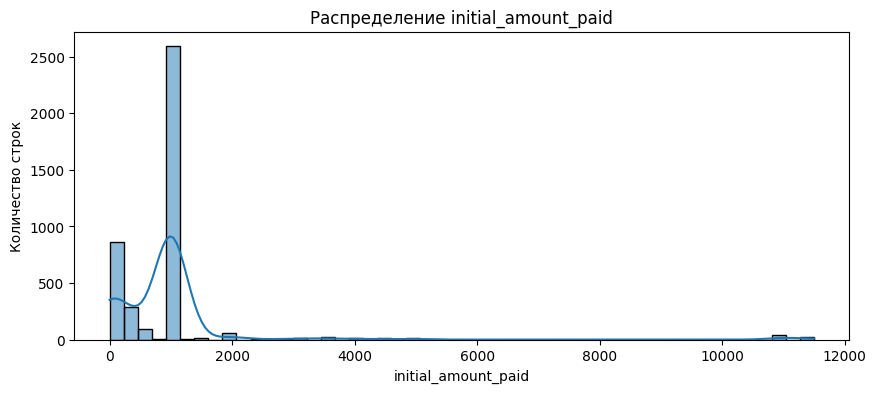

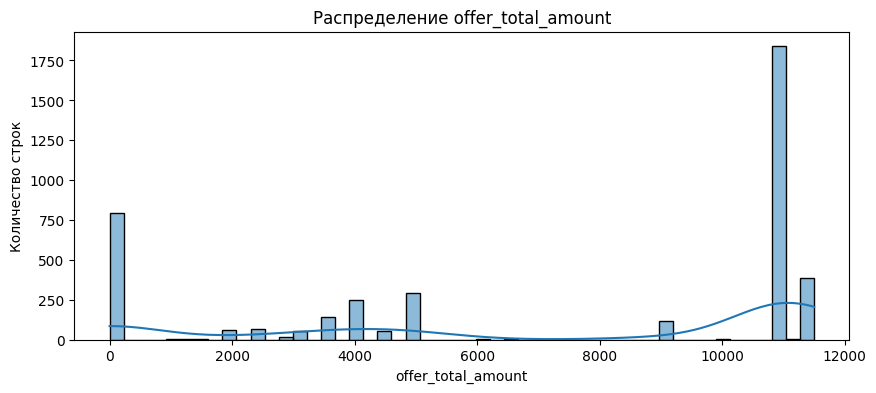

In [189]:
for col in deals_numeric_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(deals[col].dropna(), bins=50, kde=True)
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество строк")
    plt.show()


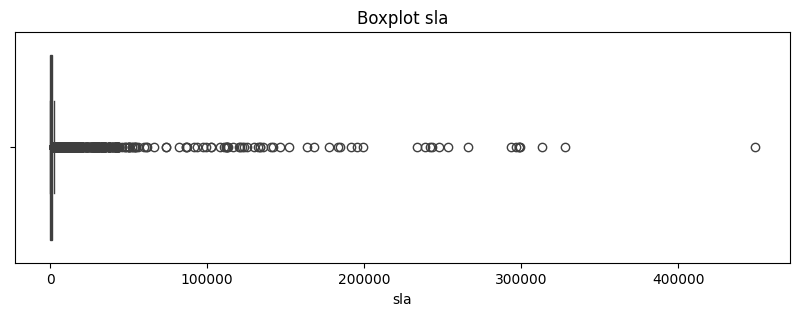

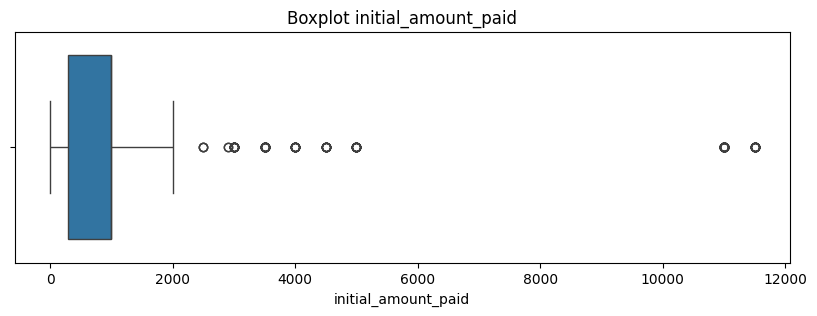

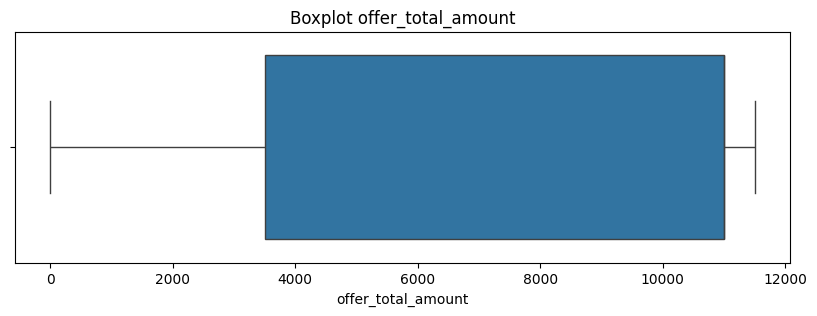

In [190]:
for col in deals_numeric_columns:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=deals[col])
    plt.title(f"Boxplot {col}")
    plt.xlabel(col)
    plt.show()

In [191]:
# Deals: выбросы по IQR

deals_outlier_summary = []

for col in deals_numeric_columns:
    outliers = iqr_outlyer(deals.dropna(subset=[col]), col, k=1.5)
    
    deals_outlier_summary.append({
        "column": col,
        "non_null": deals[col].notna().sum(),
        "outliers_count": outliers.sum(),
        "outliers_pct": round(outliers.mean() * 100, 2),
        "min": deals[col].min(),
        "q1": deals[col].quantile(0.25),
        "median": deals[col].median(),
        "q3": deals[col].quantile(0.75),
        "max": deals[col].max()})

deals_outlier_summary = pd.DataFrame(deals_outlier_summary)

deals_outlier_summary

,column,non_null,outliers_count,outliers_pct,min,q1,median,q3,max
0,sla,14997,1332,8.88,0.05,73.33,329.85,932.2,448474.4
1,initial_amount_paid,4062,142,3.50,0.00,300.00,1000.00,1000.0,11500.0
2,offer_total_amount,4082,0,0.00,0.00,3500.00,11000.00,11000.0,11500.0


# Вывод по числовым и дискретным полям Deals
Числовые поля Deals имеют много пропусков, потому что продуктовые и платежные данные заполняются не для всех потенциальных сделок, а в основном для сделок, дошедших до оплаты или обучения.

Для непрерывного числового анализа были оставлены sla, initial_amount_paid и offer_total_amount. По денежным полям initial_amount_paid и offer_total_amount наблюдаются выбросы по boxplot и правилу IQR. Такие значения не удаляем автоматически: крупные платежи и дорогие предложения могут быть реальными, а для анализа выручки мы дополнительно ориентируемся на признак is_student.

course_duration и months_of_study имеют числовой тип, но по смыслу являются дискретными категориальными полями: длительность курса и количество месяцев обучения принимают ограниченный набор значений. Поэтому для них были построены таблицы частот и столбчатые диаграммы, без поиска выбросов через IQR.

months_of_study не заполнялся искусственно и используется как основной признак фактического обучения.

Много отклонений в столбце sla, который показывает скорость реакции менеджера и также может иметь выбросы: очень большие значения могут указывать на позднюю обработку заявки или ошибку фиксации в CRM. Максимальное значение - 448474.4 минут - это 311 дней, по хорошему надо конечно все что больше нескольких месяцев удалять, так как это влияет на общую статистику работы менеджеров, но чисто гипотетически такое может случиться, что через год человек контактирует и интересуется учебой.